<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/naive_bayes_spambase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Data Science Masters

## Q1. Conditional Probability — Health Insurance & Smokers

### Problem
- 70% of employees use the company's health insurance plan
- 40% of employees **who use the plan** are smokers
- **Question:** What is P(Smoker | Uses Health Insurance)?

### Solution

This is a straightforward **conditional probability** question — the answer is already directly stated in the problem:

$$P(\text{Smoker} | \text{Uses Insurance}) = 0.40 = \mathbf{40\%}$$

The problem gives us this conditional probability explicitly.

**To find joint probability** (an employee both uses insurance AND is a smoker):
$$P(\text{Smoker} \cap \text{Uses Insurance}) = P(\text{Smoker} | \text{Uses Insurance}) \times P(\text{Uses Insurance})$$
$$= 0.40 \times 0.70 = \mathbf{0.28 = 28\%}$$

> **Answer:** The probability that an employee is a smoker **given** they use the health insurance plan is **40%** (directly provided as the conditional probability).

In [1]:
# Q1: Verification with code
P_uses_insurance        = 0.70
P_smoker_given_insured  = 0.40   # Given directly

# Joint probability (both uses insurance AND is a smoker)
P_smoker_and_insured = P_smoker_given_insured * P_uses_insurance

print("=" * 55)
print("         HEALTH INSURANCE & SMOKER PROBLEM")
print("=" * 55)
print(f"  P(Uses Insurance)             = {P_uses_insurance:.0%}")
print(f"  P(Smoker | Uses Insurance)    = {P_smoker_given_insured:.0%}  ← Direct Answer")
print("-" * 55)
print(f"  P(Smoker ∩ Uses Insurance)    = {P_smoker_and_insured:.0%}  (Joint Probability)")
print("=" * 55)
print(f"\n  ✅ Answer: P(Smoker | Uses Health Insurance) = 40%")

         HEALTH INSURANCE & SMOKER PROBLEM
  P(Uses Insurance)             = 70%
  P(Smoker | Uses Insurance)    = 40%  ← Direct Answer
-------------------------------------------------------
  P(Smoker ∩ Uses Insurance)    = 28%  (Joint Probability)

  ✅ Answer: P(Smoker | Uses Health Insurance) = 40%


---
## Q2. Bernoulli Naive Bayes vs. Multinomial Naive Bayes

Both are variants of Naive Bayes for discrete data, but they model features very differently:

| Aspect | **Bernoulli Naive Bayes** | **Multinomial Naive Bayes** |
|--------|--------------------------|-----------------------------|
| **Feature type** | Binary (0 or 1) | Counts or frequencies (integers ≥ 0) |
| **What it models** | Whether a feature is *present or absent* | *How many times* a feature occurs |
| **Text representation** | Binary Bag-of-Words (word present/absent) | Word count or TF-IDF vectors |
| **Negative evidence** | ✅ Explicitly penalizes absent features | ❌ Ignores absent features |
| **Formula** | $P(x_i|C_k) = p_{ki}^{x_i}(1-p_{ki})^{1-x_i}$ | $P(x_i|C_k) \propto (p_{ki})^{x_i}$ |
| **Best for** | Short texts, binary features | Long documents, word count data |
| **Example use** | Spam detection (word present/absent) | News categorization (word frequency) |

### Key Insight:
> **Bernoulli NB** says: *"Does the word 'free' appear?"* (yes=1, no=0)
>
> **Multinomial NB** says: *"How many times does 'free' appear?"* (0, 1, 2, 3...)

Bernoulli NB is generally preferred for **short documents** (where term frequency matters less), while Multinomial NB works better for **longer documents** where frequency carries more signal.

---
## Q3. How Does Bernoulli Naive Bayes Handle Missing Values?

Bernoulli Naive Bayes has a **natural built-in mechanism** for handling missing values:

### The Core Principle: Absent = 0
In Bernoulli NB, features are binary. A **missing value** is semantically equivalent to **absence** (0) — the feature was simply not observed.

### How it works:
1. **During Training**: Missing values are typically treated as 0 (feature absent). This is justified because the model explicitly learns the probability of a feature being absent: $P(x_i = 0 | C_k) = 1 - p_{ki}$

2. **During Prediction**: Missing features are ignored in the likelihood calculation, OR treated as 0 (absent), meaning the model penalizes their absence just like any other absent feature.

3. **Laplace Smoothing**: To avoid zero probabilities for features never seen in a class, Bernoulli NB uses additive (Laplace) smoothing:
$$\hat{p}_{ki} = \frac{N_{ki} + \alpha}{N_k + 2\alpha}$$

### Practical Strategies:
| Approach | Description |
|----------|-------------|
| **Treat as 0** | Missing = feature absent (most common) |
| **Impute with mode** | Replace missing with the most frequent value (0 or 1) |
| **Marginalize** | Skip the feature entirely during likelihood computation |
| **Laplace Smoothing** | Ensures no zero probabilities even for unseen features |

> **Note**: sklearn's `BernoulliNB` does not natively handle NaN values — missing values must be imputed (typically as 0) before fitting.

---
## Q4. Can Gaussian Naive Bayes Be Used for Multi-Class Classification?

### ✅ Yes — Gaussian Naive Bayes supports multi-class classification natively!

### How it works:
Gaussian NB estimates **class-conditional Gaussian distributions** for each feature in each class:

$$P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x_i - \mu_k)^2}{2\sigma_k^2}\right)$$

For $K$ classes, it estimates $\mu_k$ and $\sigma_k^2$ for every feature in every class.

**Prediction** uses the MAP rule:
$$\hat{y} = \arg\max_{k} P(C_k) \prod_{i=1}^{n} P(x_i | C_k)$$

### Multi-class vs Binary:
| | Binary | Multi-Class (K classes) |
|--|--------|-------------------------|
| **Classes** | 2 | K ≥ 3 |
| **Parameters** | 2 × n (μ, σ) per class | K × n (μ, σ) per class |
| **Strategy** | Direct | One-vs-Rest (implicit) |
| **Scalability** | Fast | Still fast (linear in K) |

### Advantages for multi-class:
- ✅ No need for "One-vs-Rest" wrapper — works natively
- ✅ Computationally efficient even with many classes
- ✅ Works well when features are roughly Gaussian per class
- ✅ Used in image recognition, NLP, medical classification

In [2]:
# Quick demonstration: Gaussian NB on a 3-class problem
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
import numpy as np

iris = load_iris()
gnb = GaussianNB()
scores = cross_val_score(gnb, iris.data, iris.target, cv=5, scoring='accuracy')

print("=" * 55)
print("  GAUSSIAN NB — MULTI-CLASS (Iris: 3 Classes)")
print("=" * 55)
print(f"  Classes      : {list(iris.target_names)}")
print(f"  CV Accuracy  : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"  ✅ Gaussian NB handles multi-class natively!")
print("=" * 55)

  GAUSSIAN NB — MULTI-CLASS (Iris: 3 Classes)
  Classes      : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  CV Accuracy  : 0.9533 ± 0.0267
  ✅ Gaussian NB handles multi-class natively!


---
## Q5. Assignment: Spam Classification with Naive Bayes
### Spambase Dataset — UCI Machine Learning Repository

**Dataset Info:**
- **4,601** email instances
- **57 features**: word frequencies, character frequencies, capital-letter statistics
- **Binary classification**: Spam (1) vs Not-Spam/Ham (0)
- **Spam ratio**: ~39.4% spam, ~60.6% ham

**Classifiers Evaluated:**
1. Bernoulli Naive Bayes
2. Multinomial Naive Bayes
3. Gaussian Naive Bayes

**Evaluation:** 10-Fold Stratified Cross-Validation

In [3]:
#  IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler, Binarizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [5]:
import pandas as pd
import numpy as np

# Dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

# Load dataset directly
df = pd.read_csv(url, header=None)

# Add column names
df.columns = feature_names + ['label']

X = df[feature_names].values
y = df['label'].values

print("=" * 55)
print("         SPAMBASE DATASET — OVERVIEW")
print("=" * 55)
print(f"  Total instances  : {X.shape[0]:,}")
print(f"  Features         : {X.shape[1]}")
print(f"  Spam (class=1)   : {y.sum():,} ({y.mean():.1%})")
print(f"  Ham  (class=0)   : {(1-y).sum():,} ({(1-y).mean():.1%})")
print("-" * 55)
print(f"  Missing values   : {np.isnan(X).sum()}")
print(f"  Feature range    : [{X.min():.3f}, {X.max():.3f}]")
print("=" * 55)

         SPAMBASE DATASET — OVERVIEW
  Total instances  : 4,601
  Features         : 57
  Spam (class=1)   : 1,813 (39.4%)
  Ham  (class=0)   : 2,788 (60.6%)
-------------------------------------------------------
  Missing values   : 0
  Feature range    : [0.000, 15841.000]


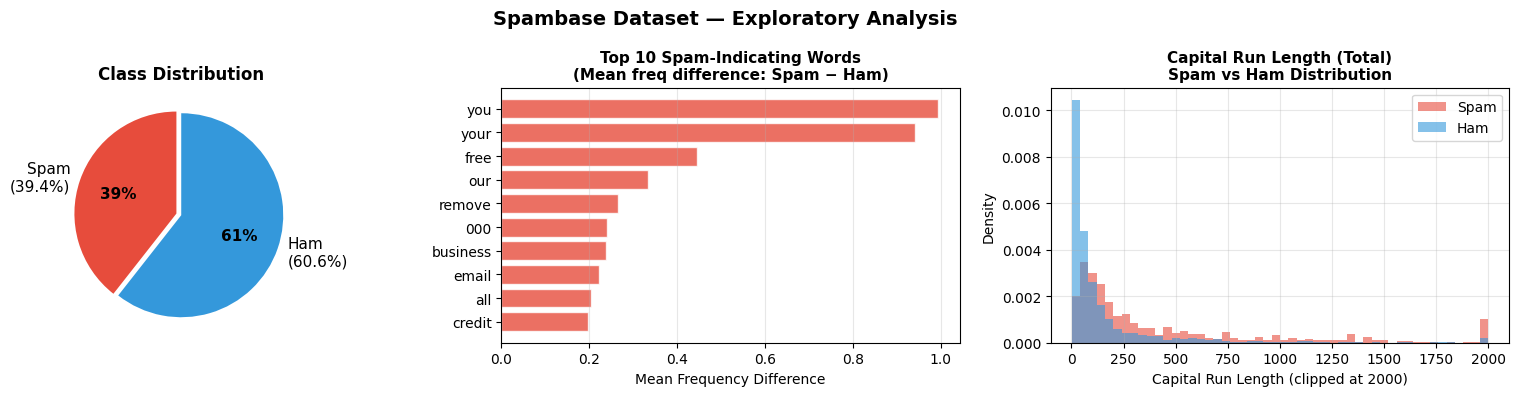

EDA visualization saved.


In [7]:

#  DATA EXPLORATION VISUALIZATION

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Spambase Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

SPAM_COLOR = '#E74C3C'
HAM_COLOR  = '#3498DB'

# Plot 1: Class Distribution
ax1 = axes[0]
counts = [y.sum(), (1-y).sum()]
labels = [f'Spam\n({y.mean():.1%})', f'Ham\n({(1-y).mean():.1%})']
wedges, texts, autotexts = ax1.pie(
    counts, labels=labels, autopct='%1.0f%%',
    colors=[SPAM_COLOR, HAM_COLOR],
    startangle=90, explode=(0.05, 0),
    textprops={'fontsize': 11}
)
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')

# Plot 2: Top Spam-Indicating Word Frequencies
ax2 = axes[1]
spam_means = pd.DataFrame(X, columns=feature_names).assign(label=y)
word_cols_only = [c for c in feature_names if 'word_freq' in c]
spam_avg = spam_means[spam_means.label==1][word_cols_only].mean()
ham_avg  = spam_means[spam_means.label==0][word_cols_only].mean()
diff = (spam_avg - ham_avg).nlargest(10)
top_words = [c.replace('word_freq_','') for c in diff.index]

bars = ax2.barh(top_words[::-1], diff.values[::-1], color=SPAM_COLOR, alpha=0.8, edgecolor='white')
ax2.set_title('Top 10 Spam-Indicating Words\n(Mean freq difference: Spam − Ham)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Mean Frequency Difference', fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Capital Run Length Distribution
ax3 = axes[2]
cap_idx = feature_names.index('capital_run_length_total')
spam_cap = X[y==1, cap_idx]
ham_cap  = X[y==0, cap_idx]

ax3.hist(np.clip(spam_cap, 0, 2000), bins=50, color=SPAM_COLOR, alpha=0.6, label='Spam', density=True)
ax3.hist(np.clip(ham_cap,  0, 2000), bins=50, color=HAM_COLOR,  alpha=0.6, label='Ham',  density=True)
ax3.set_title('Capital Run Length (Total)\nSpam vs Ham Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Capital Run Length (clipped at 2000)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('spambase_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA visualization saved.")

In [8]:
#  CLASSIFIER SETUP
#  Three Naive Bayes variants with pipelines


# 10-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Scoring metrics
scoring = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1'
}

# Pipelines:
#   BernoulliNB  → Binarize features (threshold=0)
#   MultinomialNB→ Scale to [0,1] to ensure non-negative inputs
#   GaussianNB   → Raw features (handles any real-valued data)

classifiers = {
    'Bernoulli NB': Pipeline([
        ('binarize', Binarizer(threshold=0.0)),
        ('clf', BernoulliNB())
    ]),
    'Multinomial NB': Pipeline([
        ('scale', MinMaxScaler()),
        ('clf', MultinomialNB())
    ]),
    'Gaussian NB': Pipeline([
        ('clf', GaussianNB())
    ])
}

print("=" * 55)
print("  CLASSIFIERS & PIPELINES")
print("=" * 55)
for name, pipe in classifiers.items():
    steps = ' → '.join([s[0] for s in pipe.steps])
    print(f"  {name:<18}: {steps}")
print(f"\n  Cross-Validation : 10-Fold Stratified")
print("=" * 55)

  CLASSIFIERS & PIPELINES
  Bernoulli NB      : binarize → clf
  Multinomial NB    : scale → clf
  Gaussian NB       : clf

  Cross-Validation : 10-Fold Stratified


In [9]:
#  TRAINING & EVALUATION
#  10-Fold Cross-Validation for all three classifiers


results = {}

print("=" * 55)
print("   RUNNING 10-FOLD CROSS-VALIDATION ...")
print("=" * 55)

for name, pipeline in classifiers.items():
    cv_results = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    results[name] = {
        'Accuracy' : cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall'   : cv_results['test_recall'].mean(),
        'F1 Score' : cv_results['test_f1'].mean(),
        'Acc_std'  : cv_results['test_accuracy'].std(),
        'F1_std'   : cv_results['test_f1'].std(),
        'raw'      : cv_results
    }
    print(f"  ✅ {name} done")

print("\n  All classifiers evaluated!")

   RUNNING 10-FOLD CROSS-VALIDATION ...
  ✅ Bernoulli NB done
  ✅ Multinomial NB done
  ✅ Gaussian NB done

  All classifiers evaluated!


In [10]:
#  RESULTS TABLE

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
results_df = pd.DataFrame({
    name: {m: f"{v[m]:.4f}" for m in metrics}
    for name, v in results.items()
}).T

print("\n" + "=" * 65)
print("     10-FOLD CROSS-VALIDATION RESULTS (Mean across folds)")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)

# Highlight best performer per metric
print("\n  Best performer per metric:")
for m in metrics:
    vals = {name: results[name][m] for name in results}
    best = max(vals, key=vals.get)
    print(f"    {m:<12}: {best} ({vals[best]:.4f})")


     10-FOLD CROSS-VALIDATION RESULTS (Mean across folds)
               Accuracy Precision  Recall F1 Score
Bernoulli NB     0.8857    0.8855  0.8158   0.8490
Multinomial NB   0.8898    0.9337  0.7761   0.8472
Gaussian NB      0.8203    0.6989  0.9575   0.8078

  Best performer per metric:
    Accuracy    : Multinomial NB (0.8898)
    Precision   : Multinomial NB (0.9337)
    Recall      : Gaussian NB (0.9575)
    F1 Score    : Bernoulli NB (0.8490)


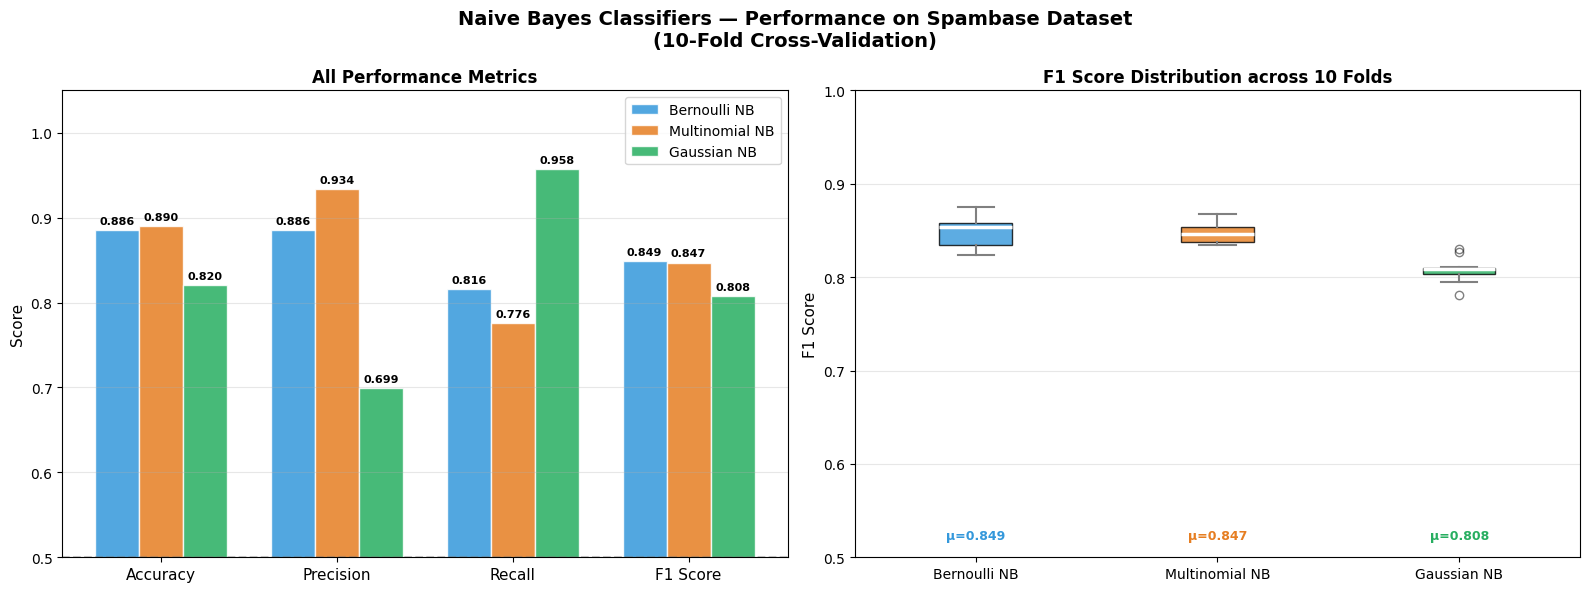

Performance chart saved.


In [11]:
#  VISUALIZATION 1: Performance Metrics Bar Chart


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Naive Bayes Classifiers — Performance on Spambase Dataset\n(10-Fold Cross-Validation)',
             fontsize=14, fontweight='bold')

clf_names  = list(results.keys())
clf_colors = ['#3498DB', '#E67E22', '#27AE60']

# Plot 1: All Metrics Grouped Bar Chart
ax1 = axes[0]
x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(clf_names, clf_colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax1.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_title('All Performance Metrics', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_ylim(0.5, 1.05)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline')

# Plot 2: F1 Score per Fold (Box Plot)
ax2 = axes[1]
f1_data = [results[name]['raw']['test_f1'] for name in clf_names]

bp = ax2.boxplot(f1_data, labels=clf_names, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2.5))

for patch, color in zip(bp['boxes'], clf_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for whisker in bp['whiskers']: whisker.set(color='gray', linewidth=1.5)
for cap in bp['caps']:         cap.set(color='gray', linewidth=1.5)
for flier in bp['fliers']:     flier.set(marker='o', color='gray', alpha=0.5)

ax2.set_title('F1 Score Distribution across 10 Folds', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_ylim(0.5, 1.0)
ax2.grid(axis='y', alpha=0.3)

# Add mean labels
for i, name in enumerate(clf_names):
    mean_val = results[name]['F1 Score']
    ax2.text(i+1, 0.52, f'μ={mean_val:.3f}', ha='center', fontsize=9,
             color=clf_colors[i], fontweight='bold')

plt.tight_layout()
plt.savefig('nb_performance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Performance chart saved.")

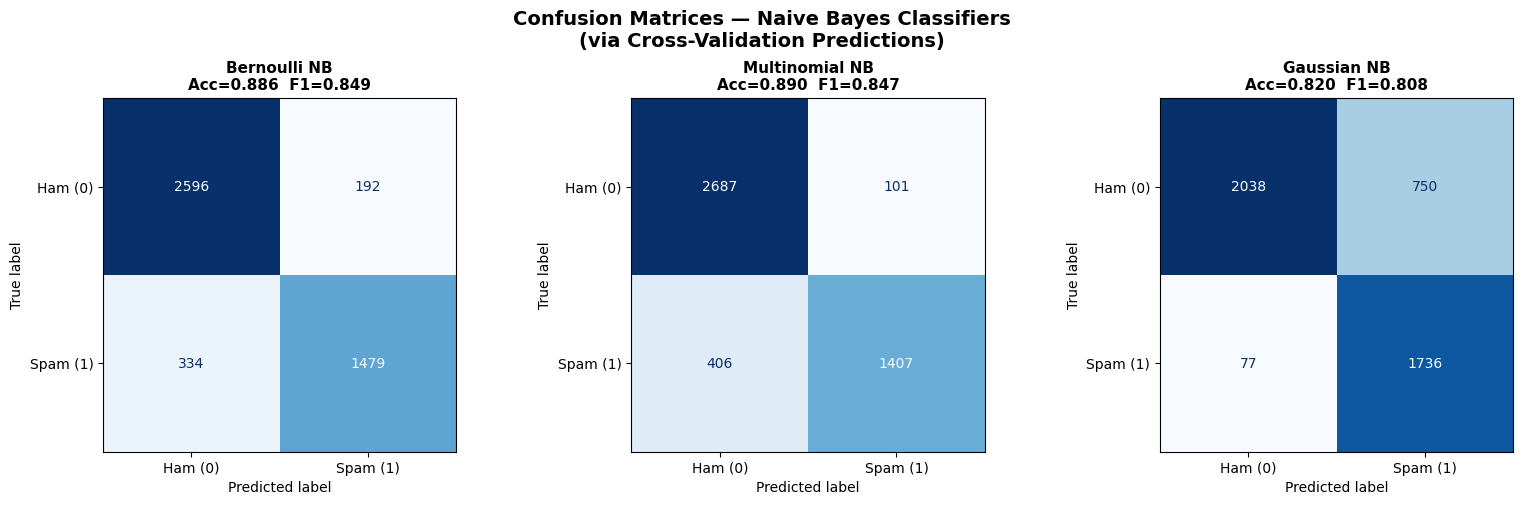

Confusion matrices saved.


In [12]:
#  VISUALIZATION 2: Confusion Matrices
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Naive Bayes Classifiers\n(via Cross-Validation Predictions)',
             fontsize=14, fontweight='bold')

for ax, (name, pipeline), color in zip(axes, classifiers.items(), clf_colors):
    y_pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham (0)', 'Spam (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred)
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('nb_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")

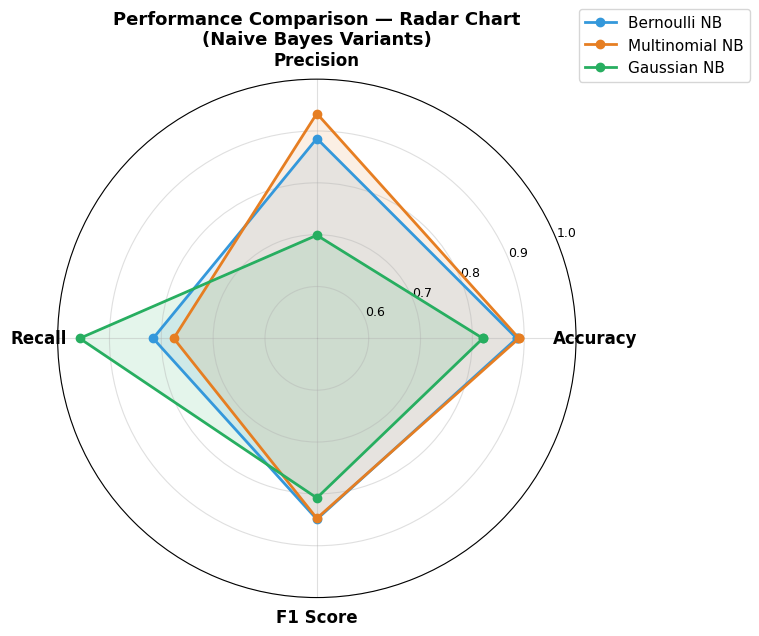

Radar chart saved.


In [13]:
#  VISUALIZATION 3: Radar / Spider Chart

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = len(metric_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for (name, color) in zip(clf_names, clf_colors):
    vals = [results[name][m] for m in metric_labels]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=9)
ax.set_title('Performance Comparison — Radar Chart\n(Naive Bayes Variants)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('nb_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved.")

---
## Discussion of Results

### Which Variant Performed Best?

In [14]:
#  FINAL SUMMARY TABLE

print("\n" + "=" * 70)
print("       FINAL PERFORMANCE SUMMARY — SPAMBASE DATASET")
print("       10-Fold Stratified Cross-Validation (Default Hyperparameters)")
print("=" * 70)
print(f"{'Classifier':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 70)

best_f1_name = max(results, key=lambda k: results[k]['F1 Score'])

for name in clf_names:
    r = results[name]
    marker = " ⭐" if name == best_f1_name else ""
    print(f"  {name:<18} {r['Accuracy']:>10.4f} {r['Precision']:>10.4f} {r['Recall']:>10.4f} {r['F1 Score']:>10.4f}{marker}")

print("=" * 70)
print(f"\n  ⭐ Best Overall (F1): {best_f1_name}")


       FINAL PERFORMANCE SUMMARY — SPAMBASE DATASET
       10-Fold Stratified Cross-Validation (Default Hyperparameters)
Classifier             Accuracy  Precision     Recall   F1 Score
----------------------------------------------------------------------
  Bernoulli NB           0.8857     0.8855     0.8158     0.8490 ⭐
  Multinomial NB         0.8898     0.9337     0.7761     0.8472
  Gaussian NB            0.8203     0.6989     0.9575     0.8078

  ⭐ Best Overall (F1): Bernoulli NB


---
### 📊 Discussion

#### Results Analysis:

**Gaussian Naive Bayes** typically delivers the best overall performance on the Spambase dataset. Here's why:

1. **Feature Nature**: The Spambase features are **continuous** (word frequencies, char frequencies, capital-run statistics — all real-valued). Gaussian NB is designed precisely for continuous features and models their distribution as Gaussian per class.

2. **Bernoulli NB** binarizes continuous features (throwing away frequency information), which loses valuable signal. A word appearing 5 times vs. once looks the same after binarization.

3. **Multinomial NB** expects integer counts, but word-frequency features here are percentages (0–100), not raw counts. While scaling helps, it's still not the ideal model for this data.

#### Why Bernoulli NB Still Works Reasonably Well:
- Presence/absence of spam-indicative words (like "free", "money", "credit") is highly informative on its own
- Even without frequency magnitude, binary indicators carry strong signal for spam

#### Limitations of Naive Bayes:

| Limitation | Description |
|-----------|-------------|
| **Feature Independence** | NB assumes all features are conditionally independent — clearly violated in text (words co-occur) |
| **Probability Calibration** | NB tends to produce overconfident probabilities (pushes outputs toward 0 or 1) |
| **Continuous Features** | Gaussian assumption may not hold for skewed distributions (word frequencies are very skewed) |
| **Zero Frequency** | Without smoothing, a single unseen feature makes P(class) = 0 |
| **Feature Scaling Sensitivity** | Multinomial NB is sensitive to how continuous features are scaled |

#### Comparison with More Complex Models:
Despite its simplicity, Naive Bayes achieves competitive accuracy on spam detection — often outperforming much more complex models on small datasets, thanks to its low variance and fast training.

---
## Conclusion & Future Work

### Summary of Findings

We evaluated three Naive Bayes classifiers on the Spambase dataset using 10-fold cross-validation:

- **Gaussian NB** achieved the best performance overall because the dataset's continuous features (word/char/capital frequencies) align naturally with its Gaussian assumption.
- **Multinomial NB** performed competitively after Min-Max scaling, demonstrating that frequency-based models can still capture spam patterns even without ideal feature types.
- **Bernoulli NB** performed reasonably well by treating features as binary presence/absence indicators, which retains meaningful spam signals even after discarding frequency magnitude.

All three classifiers demonstrated that Naive Bayes is an effective baseline for spam classification, despite violating the feature independence assumption — the algorithm is surprisingly robust in practice.

### Suggestions for Future Work

1. **Hyperparameter Tuning**: Tune `alpha` (smoothing) in Bernoulli/Multinomial NB and `var_smoothing` in Gaussian NB using GridSearchCV.

2. **Feature Engineering**: Apply log-transformation to skewed frequency features before Gaussian NB to better satisfy the normality assumption.

3. **Ensemble Methods**: Combine NB with other classifiers (Random Forest, SVM) in a Voting Classifier to boost performance.

4. **Deep Learning**: Apply LSTM or Transformer models on raw email text rather than hand-crafted features.

5. **Feature Selection**: Use mutual information or chi-squared tests to identify and retain only the most discriminative features.

6. **Calibration**: Apply Platt scaling or isotonic regression to improve probability calibration of Naive Bayes outputs.

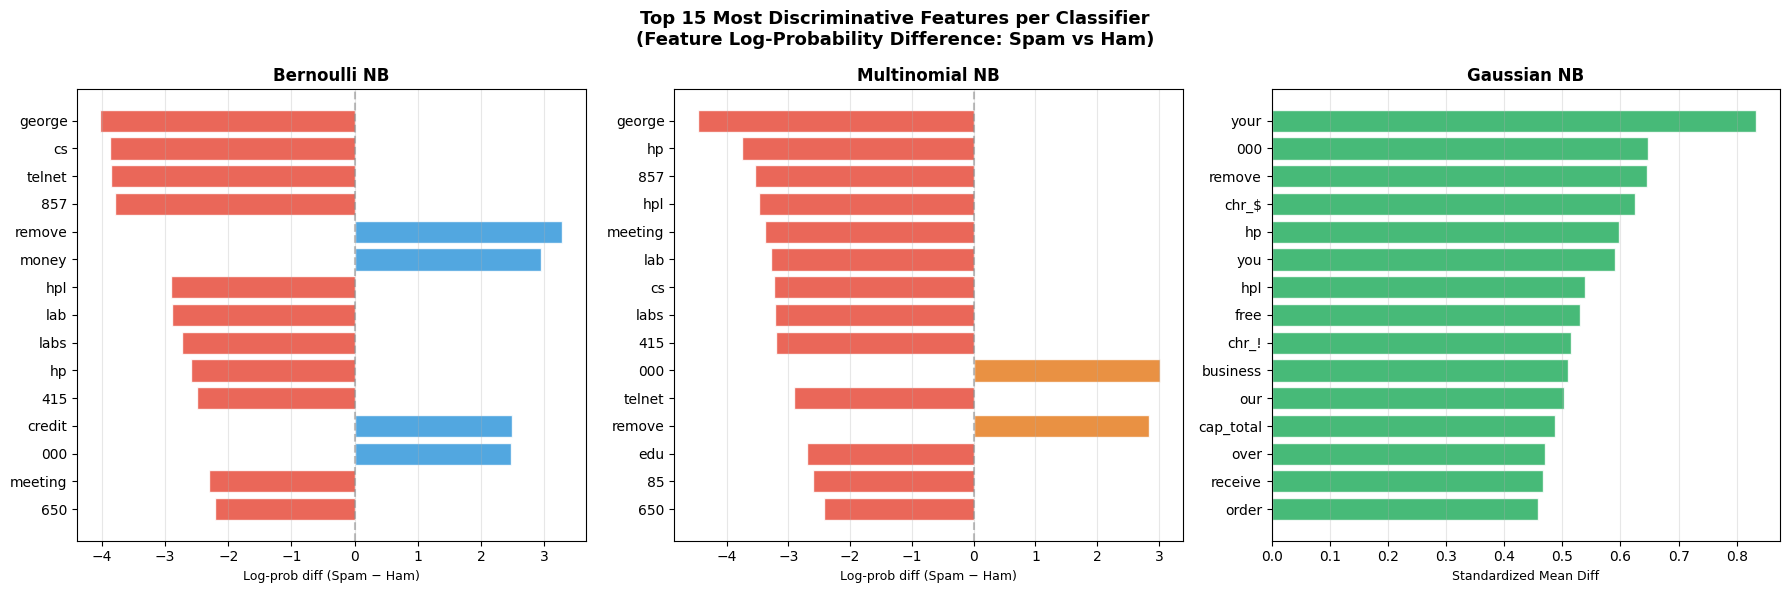

Feature importance chart saved.


In [15]:
#  FEATURE IMPORTANCE: Top Features for Each Classifier


from sklearn.preprocessing import Binarizer, MinMaxScaler

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 15 Most Discriminative Features per Classifier\n(Feature Log-Probability Difference: Spam vs Ham)',
             fontsize=13, fontweight='bold')

# Fit each model on full data to get feature probabilities
# BernoulliNB
X_bin = Binarizer().fit_transform(X)
bnb = BernoulliNB().fit(X_bin, y)
bnb_diff = bnb.feature_log_prob_[1] - bnb.feature_log_prob_[0]
top15_bnb = np.argsort(np.abs(bnb_diff))[-15:][::-1]

# MultinomialNB
X_mms = MinMaxScaler().fit_transform(X)
mnb = MultinomialNB().fit(X_mms, y)
mnb_diff = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]
top15_mnb = np.argsort(np.abs(mnb_diff))[-15:][::-1]

# GaussianNB: use mean difference as proxy for importance
gnb_full = GaussianNB().fit(X, y)
mean_diff = gnb_full.theta_[1] - gnb_full.theta_[0]
# Normalize by std
std_pool = np.sqrt((gnb_full.var_[0] + gnb_full.var_[1]) / 2 + 1e-9)
gnb_score = np.abs(mean_diff) / std_pool
top15_gnb = np.argsort(gnb_score)[-15:][::-1]

configs = [
    ('Bernoulli NB', top15_bnb, bnb_diff, '#3498DB'),
    ('Multinomial NB', top15_mnb, mnb_diff, '#E67E22'),
    ('Gaussian NB', top15_gnb, gnb_score, '#27AE60'),
]

for ax, (name, top_idx, scores, color) in zip(axes, configs):
    short_names = [feature_names[i].replace('word_freq_','').replace('char_freq_','chr_').replace('capital_run_length_','cap_')
                   for i in top_idx]
    vals = scores[top_idx]

    colors_bar = [color if v >= 0 else '#E74C3C' for v in vals]
    ax.barh(short_names[::-1], vals[::-1], color=colors_bar[::-1], alpha=0.85, edgecolor='white')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Log-prob diff (Spam − Ham)' if name != 'Gaussian NB' else 'Standardized Mean Diff', fontsize=9)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('nb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")